In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/judge-1377884607_tweet_product_company.csv', encoding='latin-1')

# Display the first 5 rows of the DataFrame
display(df.head())

# Display basic information about the DataFrame
display(df.info())

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


None

In [2]:
# Display the unique values and their counts in the target column
display(df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts())

# Drop rows where 'tweet_text' is missing
df.dropna(subset=['tweet_text'], inplace=True)

# Verify that there are no more missing values in 'tweet_text'
display(df['tweet_text'].isnull().sum())

,count
is_there_an_emotion_directed_at_a_brand_or_product,
No emotion toward brand or product,5389
Positive emotion,2978
Negative emotion,570
I can't tell,156


np.int64(0)

In [3]:
import numpy as np
import re
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Map sentiment labels to numerical values
sentiment_mapping = {
    'No emotion toward brand or product': 0,
    'Positive emotion': 1,
    'Negative emotion': 2,
    'I can\'t tell': 3
}

df['sentiment'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].map(sentiment_mapping)

# Verify the mapping
display(df[['is_there_an_emotion_directed_at_a_brand_or_product', 'sentiment']].head())

# Text cleaning function
def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'[^a-z\s]', '', text) # Remove special characters and numbers
    text = text.strip() # Remove leading/trailing whitespace
    return text

# Apply text cleaning
df['cleaned_tweet_text'] = df['tweet_text'].apply(clean_text)

# Display some cleaned tweets
display(df[['tweet_text', 'cleaned_tweet_text']].head())

# Tokenization and Padding

# Define parameters for tokenization
VOCAB_SIZE = 10000  # Max number of words to keep
MAX_LEN = 50        # Max length of a sequence

# Initialize tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<unk>')
tokenizer.fit_on_texts(df['cleaned_tweet_text'])

# Convert text to sequences of integers
X = tokenizer.texts_to_sequences(df['cleaned_tweet_text'])

# Pad sequences to a fixed length
X = pad_sequences(X, maxlen=MAX_LEN, padding='post')

# Convert target labels to categorical (one-hot encoding)
y = to_categorical(df['sentiment'], num_classes=len(sentiment_mapping))

# Display the shapes of the processed data
display(f"Shape of padded sequences (X): {X.shape}")
display(f"Shape of one-hot encoded labels (y): {y.shape}")

,is_there_an_emotion_directed_at_a_brand_or_product,sentiment
0,Negative emotion,2
1,Positive emotion,1
2,Positive emotion,1
3,Negative emotion,2
4,Positive emotion,1


,tweet_text,cleaned_tweet_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,i have a g iphone after hrs tweeting at it w...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know about awesome ipadiphone app that youll...
2,@swonderlin Can not wait for #iPad 2 also. The...,can not wait for also they should sale them ...
3,@sxsw I hope this year's festival isn't as cra...,i hope this years festival isnt as crashy as t...
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff on fri marissa mayer google tim o...


'Shape of padded sequences (X): (9092, 50)'

'Shape of one-hot encoded labels (y): (9092, 4)'

In [5]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(f"Shape of X_train: {X_train.shape}")
display(f"Shape of X_test: {X_test.shape}")
display(f"Shape of y_train: {y_train.shape}")
display(f"Shape of y_test: {y_test.shape}")

# Define the LSTM model
embedding_dim = 100 # Dimension of the word embeddings

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim),
    LSTM(units=128, dropout=0.2, recurrent_dropout=0.2),
    Dense(units=len(sentiment_mapping), activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
display(model.summary())

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=10, # Number of training epochs
    batch_size=32, # Number of samples per gradient update
    validation_data=(X_test, y_test) # Data on which to evaluate the loss and any model metrics at the end of each epoch
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
display(f"Test Loss: {loss:.4f}")
display(f"Test Accuracy: {accuracy:.4f}")

'Shape of X_train: (7273, 50)'

'Shape of X_test: (1819, 50)'

'Shape of y_train: (7273, 4)'

'Shape of y_test: (1819, 4)'

Model: "sequential_1"

...

 Non-trainable params: 0 (0.00 B)

None

Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 35s 133ms/step - accuracy: 0.5941 - loss: 0.9359 - val_accuracy: 0.5855 - val_loss: 0.9288
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 133ms/step - accuracy: 0.5944 - loss: 0.9228 - val_accuracy: 0.5855 - val_loss: 0.9244
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 29s 129ms/step - accuracy: 0.5941 - loss: 0.9215 - val_accuracy: 0.5855 - val_loss: 0.9245
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 29s 128ms/step - accuracy: 0.5944 - loss: 0.9206 - val_accuracy: 0.5855 - val_loss: 0.9238
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.5944 - loss: 0.9214 - val_accuracy: 0.5855 - val_loss: 0.9236
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 29s 128ms/step - accuracy: 0.5944 - loss: 0.9208 - val_accuracy: 0.5855 - val_loss: 0.9232
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 130ms/step - accuracy: 0.5944 - loss: 0.9210 - val_accuracy: 0.5855 - val_loss: 0.9239
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 130ms/step - accuracy: 0.5944 - loss: 0

'Test Loss: 0.9228'

'Test Accuracy: 0.5855'

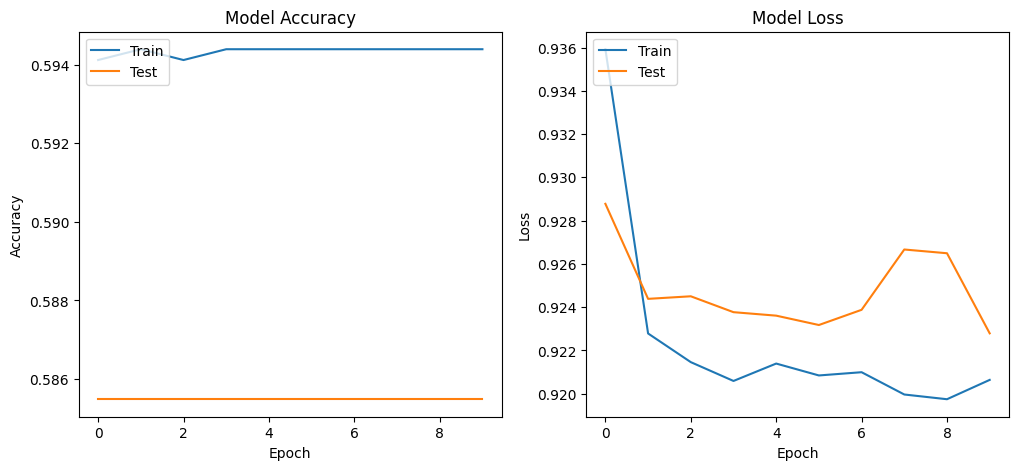

In [6]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()